# Pipeline 1: EasyOCR + LLM (Qwen 2.5)

This notebook demonstrates the first pipeline combining:
1. **EasyOCR** for text extraction from handwritten nursing notes
2. **Qwen 2.5 LLM** for processing and structuring the OCR output
3. **LLM Metrics** for evaluation

## Pipeline Flow
```
Image → EasyOCR → Raw Text → LLM (Qwen 2.5) → Structured Output → Evaluation
```

## 0. Install Dependencies

## 1. Setup and Imports

In [1]:
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Import our modules
from llm_processing.llm_pipeline import LLMPipeline
from llm_processing.prompts import get_prompt, PROMPTS
from evaluation.llm_metrics import calculate_rouge_scores, calculate_bleu_score, extract_medical_terms, calculate_information_preservation

print("✓ Imports successful")

/home/bashar/bachelor-thesis-nursing-agents/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful


## 2. Initialize EasyOCR

In [2]:
import easyocr

# Initialize EasyOCR reader for German
print("Initializing EasyOCR reader for German...")
reader = easyocr.Reader(['de'], gpu=True)
print("✓ EasyOCR reader initialized")

Initializing EasyOCR reader for German...
✓ EasyOCR reader initialized


## 3. Load Sample Image and Ground Truth

In [3]:
# Load test set
test_set_path = Path.cwd().parent / 'data' / 'test_set_500.json'
with open(test_set_path, 'r', encoding='utf-8') as f:
    test_set = json.load(f)

# Select first sample
sample = test_set['samples'][250]
print(f"Sample ID: {sample['sample_id']}")
print(f"Font: {sample['font']}")
print(f"Scenario: {sample['scenario']}")

# Load image
image_path = Path.cwd().parent / sample['image_path']
image = Image.open(image_path)

# Load ground truth
label_path = Path.cwd().parent / sample['label_path']
with open(label_path, 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

print(f"\nImage size: {image.size}")
print(f"Text length: {len(ground_truth['full_text'])} characters")

Sample ID: sample_1598
Font: MrDafoe-Regular
Scenario: Franz Lehmann

Image size: (1240, 1754)
Text length: 374 characters


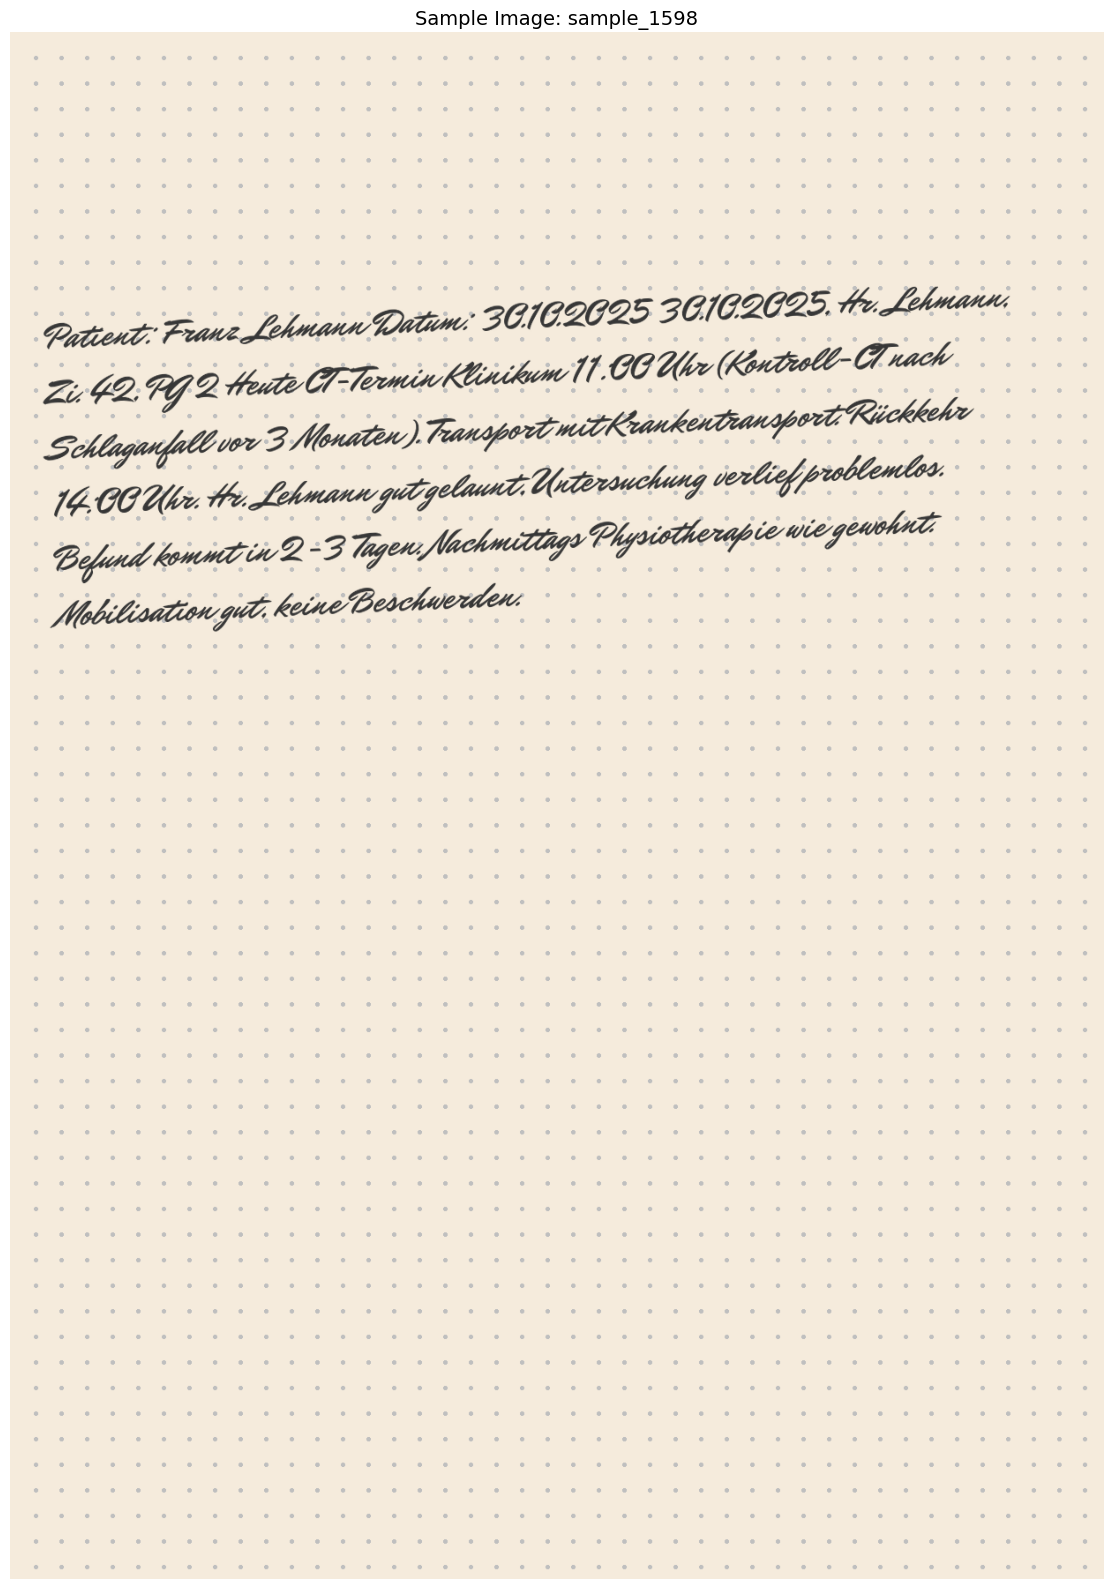

In [ ]:
# Display the image
plt.figure(figsize=(12, 16))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Sample Image: {sample['sample_id']}", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Display ground truth
print("="*80)
print("GROUND TRUTH TEXT:")
print("="*80)
print(ground_truth['original_notes'])
print("="*80)

GROUND TRUTH TEXT:
30.10.2025, Hr. Lehmann, Zi. 42, PG 2

Heute CT-Termin Klinikum 11:00 Uhr (Kontroll-CT nach Schlaganfall vor 3 Monaten). Transport mit Krankentransport.

Rückkehr 14:00 Uhr. Hr. Lehmann gut gelaunt, Untersuchung verlief problemlos. Befund kommt in 2-3 Tagen.

Nachmittags Physiotherapie wie gewohnt. Mobilisation gut, keine Beschwerden.


## 4. Run EasyOCR

In [5]:
# Run OCR
print("Running EasyOCR...")
ocr_results = reader.readtext(str(image_path))

# Extract text from results
ocr_text = ' '.join([text for (bbox, text, conf) in ocr_results])

print(f"✓ OCR completed")
print(f"Detected {len(ocr_results)} text regions")
print(f"Total OCR text length: {len(ocr_text)} characters")

Running EasyOCR...
✓ OCR completed
Detected 14 text regions
Total OCR text length: 354 characters


In [7]:
# Display OCR output with confidence scores
print("="*80)
print("EasyOCR OUTPUT (with confidence):")
print("="*80)
for i, (bbox, text, conf) in enumerate(ocr_results[:10], 1):  # Show first 10
    print(f"{i:2d}. [{conf:.3f}] {text}")
if len(ocr_results) > 10:
    print(f"... and {len(ocr_results) - 10} more regions")
print("="*80)

EasyOCR OUTPUT (with confidence):
 1. [0.114] 30102025 30102025.#; Eehmaana
 2. [0.077] Patiext: Fuane Pehmann Iataem;
 3. [0.003] 2242,792 Hn CFTGunis Kbuubsn [1 GGBlle (Koscaall-Cuack
 4. [0.741] Rickkehv
 5. [0.281] Scheaganfaed u
 6. [0.357] 'vov3 Monaten) 
 7. [0.076] Tuanapozb witKeankenbianapoa
 8. [0.020] 14-8O Brvs #u sBehmann 5
 9. [0.149] 'Zutorsuchung
10. [0.211] 'verluk poblemeos
... and 4 more regions


In [8]:
# Display full OCR text
print("="*80)
print("FULL OCR TEXT:")
print("="*80)
print(ocr_text)
print("="*80)

FULL OCR TEXT:
30102025 30102025.#; Eehmaana Patiext: Fuane Pehmann Iataem; 2242,792 Hn CFTGunis Kbuubsn [1 GGBlle (Koscaall-Cuack Rickkehv Scheaganfaed u 'vov3 Monaten)  Tuanapozb witKeankenbianapoa 14-8O Brvs #u sBehmann 5 'Zutorsuchung 'verluk poblemeos Behund kommdin%-3 Tagew; Machmitings Physiotherapie nie geushaa Mobiliaatiowgnat: keinefBeschwezdens "gigelause:


## 5. Initialize LLM Pipeline (Qwen 2.5)

In [9]:
# Check available prompts
print("Available prompts:")
print("="*80)
for name, prompt in PROMPTS.items():
    print(f"\n{name}:")
    print(f"  {prompt['description']}")
print("="*80)

Available prompts:

nursing_summary:
  Summarize nursing notes and extract key features

critical_info_extraction:
  Extract critical medical information only

care_plan_generation:
  Generate a care plan based on the notes

risk_assessment:
  Assess patient risks from nursing notes

simple_summary:
  Simple one-paragraph summary


In [10]:
# Initialize LLM pipeline with Qwen 2.5
# Using the smaller 1.5B model for faster testing
# You can change to 'qwen-3b' or 'qwen-7b' for better quality

pipeline = LLMPipeline(
    model_name='qwen-3b',  # Options: 'qwen-1.5b', 'qwen-3b', 'qwen-7b'
    prompt_name='nursing_summary',  # Change to test different prompts
    device='cuda',  # Use 'cpu' if no GPU available
    load_in_4bit=False,  # Set to True to save memory
    max_new_tokens=512,
    temperature=0.7,
    do_sample=True
)

print("\n✓ LLM Pipeline initialized and ready")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:01<00:00, 351.70it/s, Materializing param=model.norm.weight]                              



✓ LLM Pipeline initialized and ready


## 6. Process OCR Text with LLM

In [11]:
# Process the OCR text with LLM
print("Processing OCR text with Qwen 2.5-3B...")
llm_output = pipeline.process_text(ocr_text)
print("✓ LLM processing completed")

Processing OCR text with Qwen 2.5-3B...
✓ LLM processing completed


In [12]:
# Display LLM output
print("="*80)
print("LLM OUTPUT (Qwen 2.5 - Nursing Summary):")
print("="*80)
print(llm_output)
print("="*80)

LLM OUTPUT (Qwen 2.5 - Nursing Summary):
### 1. Zusammenfassung
Die Pflegenotiz befasst sich mit einer Patientenbehandlung namens Fuane Pehmann. Der Patient hat eine chronische Erkrankung (Koscaall-Cuack Rickkehv), die in den letzten drei Monaten stabil war. Der letzte Besuch am 14. August zeigte einen Zustand mit möglichen Problemen und Symptomen, die durch eine Zustandsuntersuchung untersucht werden sollten. Es wurde kein Antriebsmoment (Mobiliaatiowgnat) ermittelt, da keine Beschwerden gemeldet wurden.

### 2. Wichtige Merkmale
- **Patient**: Fuane Pehmann
- **Erkrankung**: Koscaall-Cuack Rickkehv
- **Chronischer Zustand**: In den letzten drei Monaten stabil
- **Letzter Besuch**: 14. August (Zustand mit möglichen Problemen)
- **Folgende Maßnahmen**:
  - Zustandsuntersuchung durchgeführt
  - Noch nicht angetroffenes Antriebsmoment (Mobiliaatiowgnat)

### 3. Vorschläge
- **Zustandsuntersuchung**: Durchführen Sie eine weitere Zustandsuntersuchung umfassend, um mögliche Symptome und Pro

## 7. Evaluate LLM Output

In [13]:
# Calculate ROUGE scores (comparing LLM output to ground truth)
rouge_scores = calculate_rouge_scores(
    reference=ground_truth['original_notes'],
    hypothesis=llm_output
)

print("ROUGE Scores (LLM vs Ground Truth):")
print("="*80)
print(f"ROUGE-1:")
print(f"  Precision: {rouge_scores['rouge1_precision']:.2f}%")
print(f"  Recall:    {rouge_scores['rouge1_recall']:.2f}%")
print(f"  F1:        {rouge_scores['rouge1_f1']:.2f}%")
print(f"\nROUGE-2:")
print(f"  Precision: {rouge_scores['rouge2_precision']:.2f}%")
print(f"  Recall:    {rouge_scores['rouge2_recall']:.2f}%")
print(f"  F1:        {rouge_scores['rouge2_f1']:.2f}%")
print(f"\nROUGE-L:")
print(f"  Precision: {rouge_scores['rougeL_precision']:.2f}%")
print(f"  Recall:    {rouge_scores['rougeL_recall']:.2f}%")
print(f"  F1:        {rouge_scores['rougeL_f1']:.2f}%")
print("="*80)

ROUGE Scores (LLM vs Ground Truth):
ROUGE-1:
  Precision: 4.57%
  Recall:    17.31%
  F1:        7.23%

ROUGE-2:
  Precision: 0.51%
  Recall:    1.96%
  F1:        0.81%

ROUGE-L:
  Precision: 3.55%
  Recall:    13.46%
  F1:        5.62%


In [14]:
# Calculate BLEU score
bleu_score = calculate_bleu_score(
    reference=ground_truth['original_notes'],
    hypothesis=llm_output
)

print(f"BLEU Score: {bleu_score:.2f}%")

BLEU Score: 0.13%


In [15]:
# Medical term preservation
medical_terms_ref = extract_medical_terms(ground_truth['original_notes'])
medical_terms_hyp = extract_medical_terms(llm_output)

preservation = calculate_information_preservation(
    reference=ground_truth['original_notes'],
    summary=llm_output
)

# Calculate missing and extra terms
missing_terms = medical_terms_ref - medical_terms_hyp
extra_terms = medical_terms_hyp - medical_terms_ref

print("\nMedical Term Preservation:")
print("="*80)
print(f"Terms in reference:  {preservation['terms_in_reference']}")
print(f"Terms in summary:    {preservation['terms_in_summary']}")
print(f"Terms preserved:     {preservation['terms_preserved']}")
print(f"Precision:           {preservation['medical_term_precision']:.2f}%")
print(f"Recall:              {preservation['medical_term_recall']:.2f}%")
print(f"F1:                  {preservation['medical_term_f1']:.2f}%")

if missing_terms:
    print(f"\nMissing terms ({len(missing_terms)}):")
    for term in sorted(missing_terms)[:10]:
        print(f"  - {term}")
    if len(missing_terms) > 10:
        print(f"  ... and {len(missing_terms) - 10} more")

if extra_terms:
    print(f"\nExtra terms ({len(extra_terms)}):")
    for term in sorted(extra_terms)[:10]:
        print(f"  - {term}")
    if len(extra_terms) > 10:
        print(f"  ... and {len(extra_terms) - 10} more")

print("="*80)


Medical Term Preservation:
Terms in reference:  5
Terms in summary:    7
Terms preserved:     3
Precision:           42.86%
Recall:              60.00%
F1:                  50.00%

Missing terms (2):
  - mittags
  - mobilisation

Extra terms (4):
  - behandlung
  - hand
  - patient
  - stabil


## 8. Visualize Results

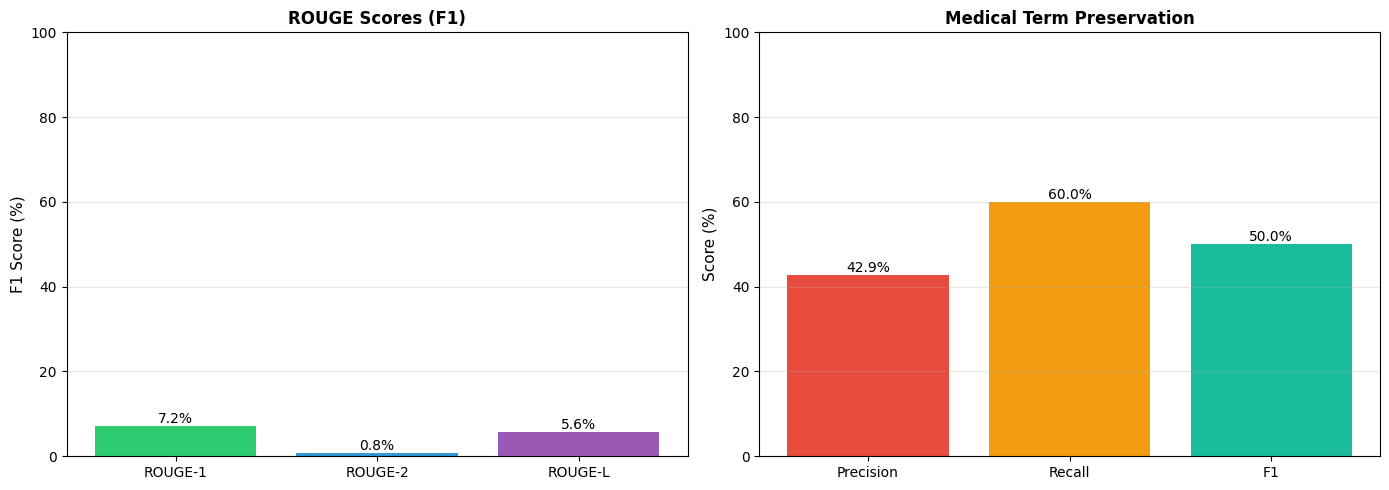

In [16]:
# Create visualization of metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROUGE scores
ax1 = axes[0]
rouge_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
f1_scores = [
    rouge_scores['rouge1_f1'],
    rouge_scores['rouge2_f1'],
    rouge_scores['rougeL_f1']
]
bars1 = ax1.bar(rouge_metrics, f1_scores, color=['#2ecc71', '#3498db', '#9b59b6'])
ax1.set_ylabel('F1 Score (%)', fontsize=11)
ax1.set_title('ROUGE Scores (F1)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Medical term preservation
ax2 = axes[1]
preservation_metrics = ['Precision', 'Recall', 'F1']
preservation_scores = [
    preservation['medical_term_precision'],
    preservation['medical_term_recall'],
    preservation['medical_term_f1']
]
bars2 = ax2.bar(preservation_metrics, preservation_scores, color=['#e74c3c', '#f39c12', '#1abc9c'])
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('Medical Term Preservation', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Summary

In [17]:
# Create summary
summary = f"""
{'='*80}
PIPELINE SUMMARY: EasyOCR + Qwen 2.5 LLM
{'='*80}

Sample: {sample['sample_id']}
Font: {sample['font']}

OCR Performance:
  - Detected regions: {len(ocr_results)}
  - OCR text length: {len(ocr_text)} chars
  - Ground truth length: {len(ground_truth['full_text'])} chars

LLM Performance (Qwen 2.5):
  - Model: {pipeline.model_name}
  - Prompt: {pipeline.prompt_name}
  - Output length: {len(llm_output)} chars

Evaluation Metrics:
  ROUGE-1 F1:     {rouge_scores['rouge1_f1']:.2f}%
  ROUGE-2 F1:     {rouge_scores['rouge2_f1']:.2f}%
  ROUGE-L F1:     {rouge_scores['rougeL_f1']:.2f}%
  BLEU Score:     {bleu_score:.2f}%
  
  Medical Terms:
    Precision:    {preservation['medical_term_precision']:.2f}%
    Recall:       {preservation['medical_term_recall']:.2f}%
    F1:           {preservation['medical_term_f1']:.2f}%

{'='*80}
"""

print(summary)


PIPELINE SUMMARY: EasyOCR + Qwen 2.5 LLM

Sample: sample_1598
Font: MrDafoe-Regular

OCR Performance:
  - Detected regions: 14
  - OCR text length: 354 chars
  - Ground truth length: 374 chars

LLM Performance (Qwen 2.5):
  - Model: Qwen/Qwen2.5-3B-Instruct
  - Prompt: nursing_summary
  - Output length: 1542 chars

Evaluation Metrics:
  ROUGE-1 F1:     7.23%
  ROUGE-2 F1:     0.81%
  ROUGE-L F1:     5.62%
  BLEU Score:     0.13%

  Medical Terms:
    Precision:    42.86%
    Recall:       60.00%
    F1:           50.00%




## 10. Next Steps

You can now:
1. **Test different LLM models**: Change `model_name` to `'qwen-3b'` or `'qwen-7b'` for better quality
2. **Test different prompts**: Try `'critical_info_extraction'`, `'care_plan_generation'`, `'risk_assessment'`, or `'simple_summary'`
3. **Test with more samples**: Loop through multiple samples from the test set
4. **Compare with other OCR methods**: Create similar notebooks for PaddleOCR, Tesseract, etc.
5. **Run batch evaluation**: Process the entire test set and aggregate metrics